<a href="https://colab.research.google.com/github/koliraj7580-debug/ML-Practical_01/blob/main/Practical_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Student Name : Koli Raj Mohan
*   Div : A
*   Practical Batch : A2
*   Roll No : 58
*   Date : 29/09/2026
*   Practical No : 04
*   Practical Name :   Implement and visualize k-Nearest Neighbors classification. Tune k and
compare accuracy.


1. Import Libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

LOAD CSV

In [21]:
df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15600000    Male   41            71570          1
1  15600001  Female   28            16015          1
2  15600002    Male   25            76813          0
3  15600003    Male   53            42712          1
4  15600004    Male   55           115497          1


2. EDA

In [22]:
print(df.shape)  #(rows, coulmns)

(400, 5)


In [34]:
df['Purchased'].value_counts()

,count
Purchased,
1,260
0,140


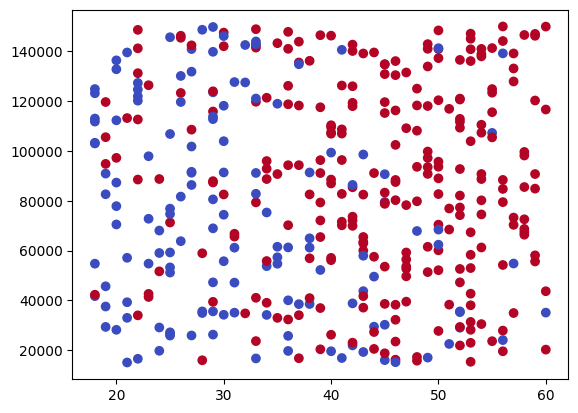

In [24]:
#Scatter Plot to show Unlinear data
plt.scatter(df['Age'], df['EstimatedSalary'], cmap='coolwarm', c=df['Purchased'])

3. Feature Selection




Select features and target

In [25]:
X = df[['Age', 'EstimatedSalary']]  #Features
y = df['Purchased']  #Target

Split data

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scale the data

In [27]:
scaler = StandardScaler() # mean=0, std=1

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Model Building

Train KNN

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(y_pred)

[0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 1
 0 1 0 1 1 1]


In [29]:
# Classification report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7375


Visualize KNN classification

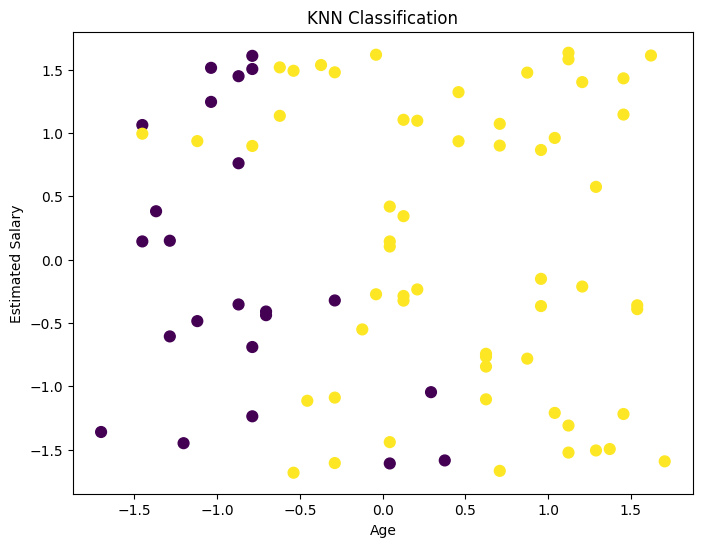

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', s=60)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("KNN Classification")
plt.show()

Tune K
*  Train no of k values






In [37]:
k_values = range(1, 16)
accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print("K", k, "Accuracy =", round(accuracy, 3))

K 1 Accuracy = 0.725
K 2 Accuracy = 0.713
K 3 Accuracy = 0.775
K 4 Accuracy = 0.762
K 5 Accuracy = 0.738
K 6 Accuracy = 0.75
K 7 Accuracy = 0.75
K 8 Accuracy = 0.762
K 9 Accuracy = 0.738
K 10 Accuracy = 0.75
K 11 Accuracy = 0.775
K 12 Accuracy = 0.8
K 13 Accuracy = 0.775
K 14 Accuracy = 0.8
K 15 Accuracy = 0.775


5. Model Evaluation

Plot K vs Accuracy

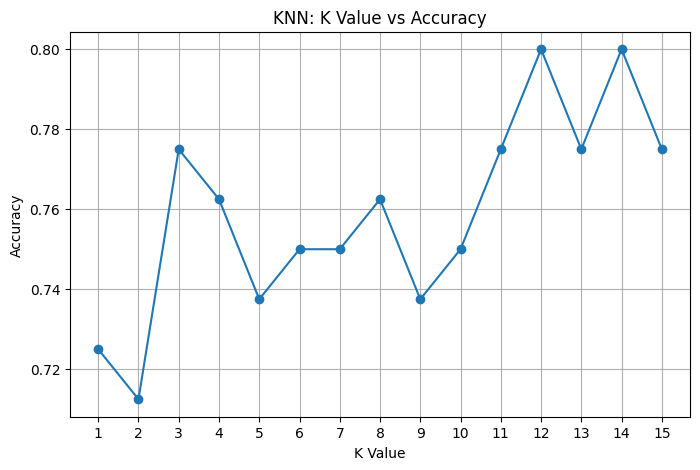

In [32]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o') #Line Plot

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)
plt.grid()

plt.show()

In [33]:
# Finding best k and accuracy value
best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 12
Best Accuracy: 0.8
